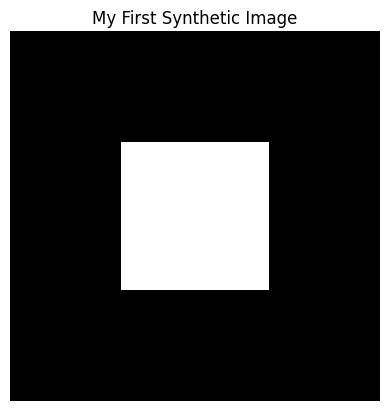

In [30]:
# 1. Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 2. Create a 10x10 matrix filled with zeros (0 = Pure Black)
synthetic_image = np.zeros((10, 10))

# 3. Modify the center pixels to be 255 (255 = Pure White)
# Slicing: rows 3 to 6, columns 3 to 6
synthetic_image[3:7, 3:7] = 255

# 4. Display the matrix as a visual image
plt.imshow(synthetic_image, cmap='gray')
plt.title("My First Synthetic Image")
plt.axis('off')  # Hide the axis lines and numbers
plt.show()

# Print the underlying matrix to see the numbers behind the picture
# print("The underlying matrix:\n", synthetic_image) 

# NumPy Image Processing: Matrix Operations

An image is just a NumPy array with shape **(H × W × 3)** — height, width, and RGB channels.  
This notebook makes NumPy concepts like slicing, broadcasting, and dtype **visually concrete**.

**What we'll do:**
- Load an image as a NumPy array
- Invert colors (broadcasting)
- Convert to grayscale (vectorized dot product)
- Flip horizontally and vertically (slicing)
- Isolate and manipulate RGB channels
- Crop a region of interest

> **Note:** You'll need a sample image. Save any `.jpg` or `.png`
> in the same folder as this notebook and update `FILENAME` below.


### 1. Setup

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("NumPy version      :", np.__version__)

NumPy version      : 2.4.4


## 2. Load Image as a NumPy Array

'PIL' loads the image, then we convert it to a 'uint8' NumPy array.
Shape will be **(H, W, 3)** - one value per RGB channel per pixel.

dtype : uint8
shape : (150, 335, 3)
min / max : 44 / 255


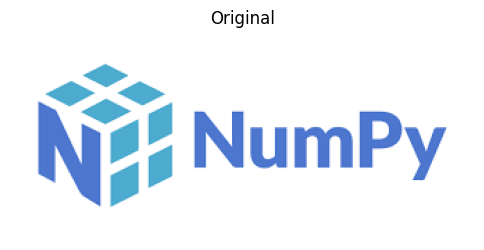

In [32]:
FILENAME = "sample.png"  # change to your image file name

img = np.array(Image.open(FILENAME).convert("RGB"), dtype=np.uint8)

print("dtype :", img.dtype)
print("shape :", img.shape)
print("min / max :", img.min(), "/", img.max())

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()

## 3. Step 1 - Color Inversion (Broadcasting)

Subtracting every pixel value from 255 flips the color space.
Dark becomes light, light becomes dark.

- Broadcasting example: '255 - img' applies to every element at once.

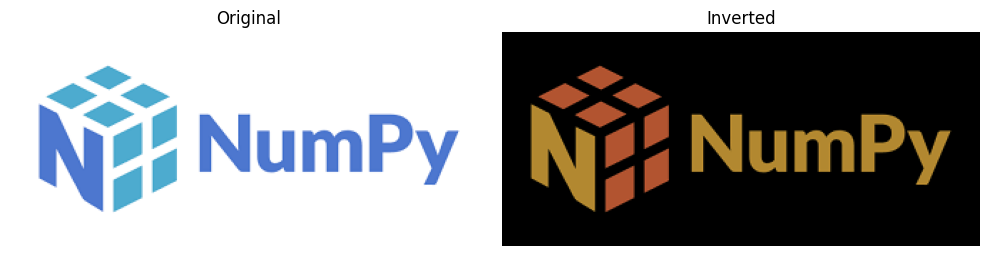

In [33]:
inverted = 255 - img

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img);       axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(inverted);  axes[1].set_title("Inverted");   axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Step 2 - Grayscale Conversion (Weighted Dot Product)

Human eyes are most sensitive to green, least to blue.
The standard ITU-R formula weights each channel accordingly:

$$Y = 0.299R + 0.587G + 0.114B$$

- Vectorized operation: applied across the entire pixel matrix in one line.
- Output shape: **(H, w)** - 2D.

Grayscale shape: (150, 335)


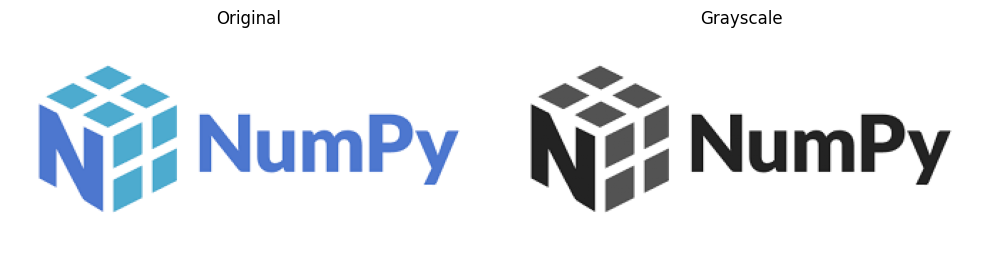

In [34]:
gray = np.dot(img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

print("Grayscale shape:", gray.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img);              axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Grayscale"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Step 3 - Flip with Slicing

NumPy slicing lets us reverse rows or columns directly - no loops.

- **Horizontal flip:** 'img[:, ::-1, :]' - reverse columns
- **Vertical flip:** 'img[::-1, :, :]' - reverse rows

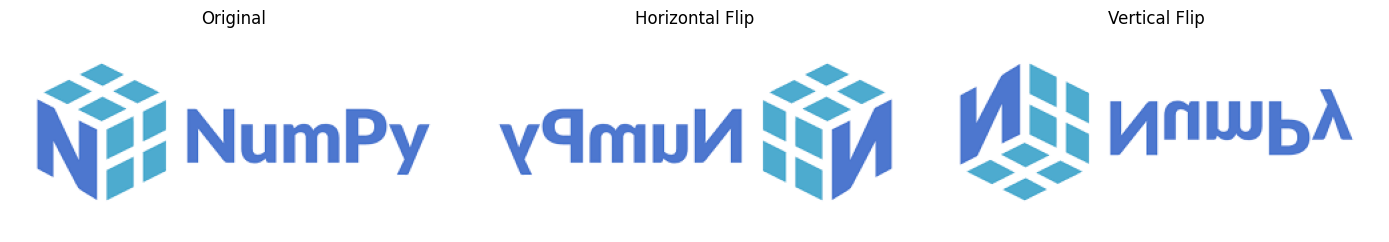

In [35]:
flip_h = img[:, ::-1, :]     # horizontal (mirror)
flip_v = img[::-1, :, :]     # vertical   (upside-down)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img);     axes[0].set_title("Original");           axes[0].axis("off")
axes[1].imshow(flip_h);  axes[1].set_title("Horizontal Flip");    axes[1].axis("off")
axes[2].imshow(flip_v);  axes[2].set_title("Vertical Flip");      axes[2].axis("off")
plt.tight_layout()
plt.show()

## 6. Step 4 - RGB Channel Isolation

Each channel index: '0 = Red', '1 = Green', '2 = Blue'.
We zero out the other two channels to isolate one color.

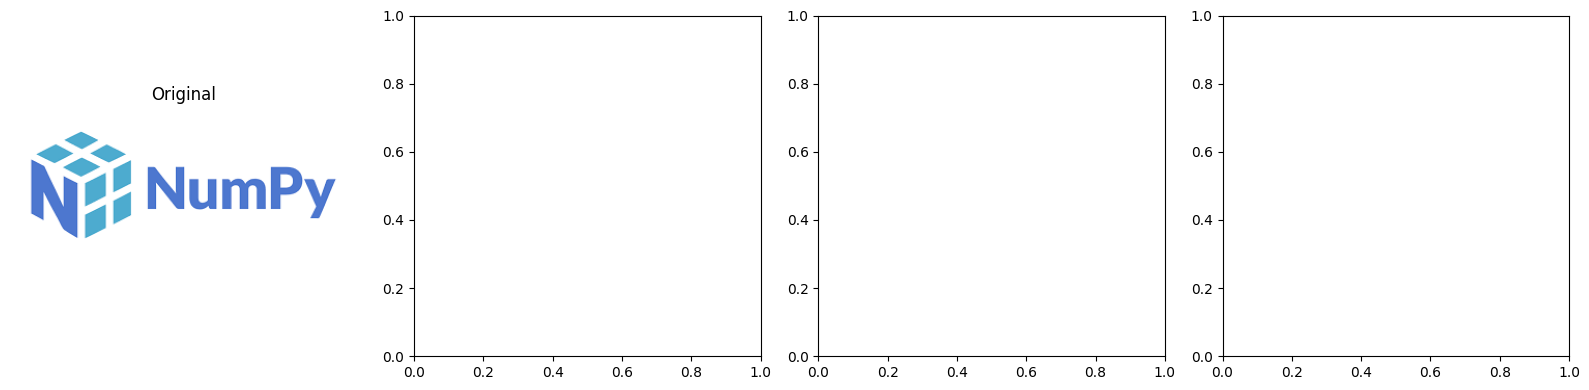

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [36]:
# Isolate each channel
red_only    = img.copy(); red_only[:, :, 1] = 0; red_only[:, :, 2] = 0
green_only  = img.copy(); green_only[:, :, 0] = 0; green_only[:, :, 2] = 0
blue_only   = img.copy(); blue_only[:, :, 0] = 0; blue_only[:, :, 1] = 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, image, title in zip(
    axes,
    [img, red_only, green_only, blue_only],
    ["Original", "Red Channel", "Green Channel", "Blue Channel"]
):
     ax.imshow(image); ax.set_title(title); ax.axis("off")

     plt.tight_layout()
     plt.show()

## 7. Step 5 - Crop a Region of Interest (Slicing)

Cropping is simply 2D array slicing: 'img[row_start:row_end, col_start:col_end]'.
No special function needed - pure NumPy indexing.


Original shape: (150, 335, 3)
Cropped shape : (75, 167, 3)


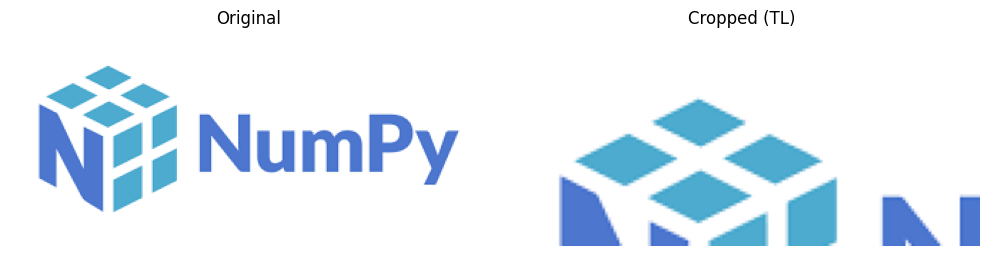

In [37]:
# Crop the top-left quarter of the image
h, w = img.shape[:2]
crop = img[:h//2, :w//2]

print("Original shape:", img.shape)
print("Cropped shape :", crop.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img);   axes[0].set_title("Original");       axes[0].axis("off")
axes[1].imshow(crop);  axes[1].set_title("Cropped (TL)");   axes[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Brigthness Adjustment (Clipping)

Adding a constant to every pixel increases brightness.
'np.clip' keeps values inside the valid '[o, 255]' range.

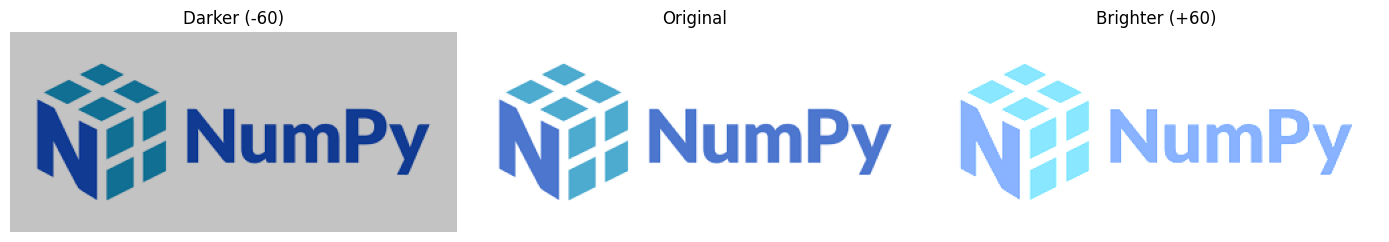

In [38]:
brighter = np.clip(img.astype(int) + 60, 0, 255).astype(np.uint8)
darker   = np.clip(img.astype(int) - 60, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(darker);    axes[0].set_title("Darker (-60)");   axes[0].axis("off")
axes[1].imshow(img);       axes[1].set_title("Original");       axes[1].axis("off")
axes[2].imshow(brighter);  axes[2].set_title("Brighter (+60)");  axes[2].axis("off")
plt.tight_layout()
plt.show()

### Summary - NumPy Concepts Used

| Operation | NumPy Concept |
|---|---|
| Color inversion | Broadcasting (`255 - img`) |
| Grayscale | Vectorized dot product |
| Flip | Array slicing (`::-1`) |
| Channel isolation | Index + assignment |
| Crop | 2D slicing |
| Brightness | Arithmetic + `np.clip` |

> Every operation ran without a single Python loop -
> this is the core power of NumPy vectorization.



Note: This notebook requires an image file named sample.png in the same directory to function correctly.